In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    weights=[0.9, 0.1],
    random_state=42
)

In [3]:
print(f"X.shape : {X.shape}")
print(pd.Series(y).value_counts())

X.shape : (1000, 10)
0    897
1    103
Name: count, dtype: int64


In [4]:
from imblearn.over_sampling import SMOTE

# 1. SMOTE 객체 생성
smote = SMOTE(random_state=42)

# 2. 훈련 데이터에만 적용 (검증/테스트 데이터 적용 금지)
X_train_res, y_train_res = smote.fit_resample(X, y)

# 3. 샘플링 후 클래스 비율 확인
print(np.bincount(y_train_res)) # 두 클래스의 개수가 같아짐

[897 897]


In [5]:
from imblearn.over_sampling import SMOTE
import numpy as np

# 각 클래스별로 원하는 최종 샘플 수 지정 (예: 각 200개씩)
target_dict = {0: 1000, 1: 1000}

smote = SMOTE(sampling_strategy=target_dict, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X, y)

print(np.bincount(y_train_res))
# 출력 결과: [200 200 200]

[1000 1000]


In [6]:
# 기존 최대 클래스 개수(51개)의 3배(153개)로 증량
multiplier = 3
max_count = np.max(np.bincount(y))
target_dict = {label: max_count * multiplier for label in np.unique(y)}

smote = SMOTE(sampling_strategy=target_dict, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X, y)

print(np.bincount(y_train_res))
# 출력 결과: [153 153 153]

[2691 2691]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek

# 1. 불균형 데이터셋 생성 (샘플 2000개, 소수 클래스 비율 약 10%)
X, y = make_classification(
    n_samples=2000, n_features=20, n_informative=10,
    n_clusters_per_class=1, weights=[0.9, 0.1], random_state=42
)

# Train / Test 분할 (stratify로 데이터 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 2. 비교할 샘플링 기법 정의
samplers = {
    'Baseline (No Sampling)': None,
    'SMOTE': SMOTE(random_state=42),
    'Borderline-SMOTE': BorderlineSMOTE(random_state=42),
    'SMOTE-Tomek': SMOTETomek(random_state=42)
}

# 3. 샘플링 적용, 모델 학습 및 성과 비교
results = []

for name, sampler in samplers.items():
    if sampler is not None:
        # Data Leakage 방지를 위해 훈련 데이터에만 샘플링 적용
        X_res, y_res = sampler.fit_resample(X_train, y_train)
    else:
        X_res, y_res = X_train, y_train

    # 모델 학습
    model = RandomForestClassifier(random_state=42)
    model.fit(X_res, y_res)

    # 예측
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # 지표 계산 (소수 클래스 기준)
    results.append({
        'Technique': name,
        'Train Size': len(y_res),
        'Class 1 Count': np.sum(y_res == 1),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    })

# 4. 결과 비교 테이블 출력
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

             Technique  Train Size  Class 1 Count  Recall  Precision  F1-Score  ROC-AUC
Baseline (No Sampling)        1400            148  0.7656     1.0000    0.8673   0.9640
                 SMOTE        2504           1252  0.9062     0.9206    0.9134   0.9664
      Borderline-SMOTE        2504           1252  0.9062     0.9206    0.9134   0.9651
           SMOTE-Tomek        2504           1252  0.9062     0.9206    0.9134   0.9664


/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_15400/91179952.py:56: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_15400/91179952.py:56: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_15400/91179952.py:56: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_15400/91179952.py:56: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_15400/91179952.py:56: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_15

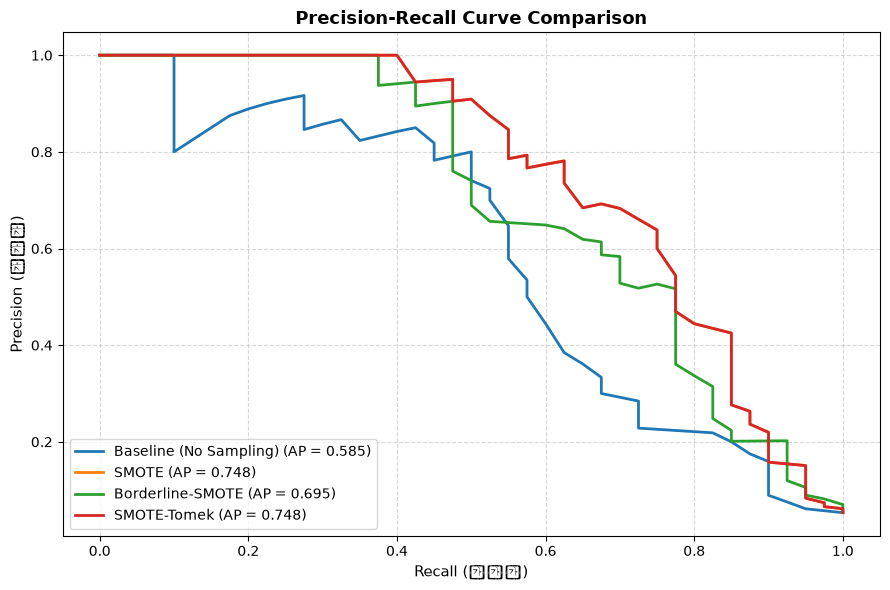

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek

# 1. 극단적인 불균형 데이터셋 생성 (소수 클래스 약 5%)
X, y = make_classification(
    n_samples=2500, n_features=20, n_informative=10,
    weights=[0.95, 0.05], random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 2. 샘플러 정의
samplers = {
    'Baseline (No Sampling)': None,
    'SMOTE': SMOTE(random_state=42),
    'Borderline-SMOTE': BorderlineSMOTE(random_state=42),
    'SMOTE-Tomek': SMOTETomek(random_state=42)
}

# 3. 시각화 설정
plt.figure(figsize=(9, 6))

for name, sampler in samplers.items():
    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
    else:
        X_res, y_res = X_train, y_train

    # 모델 학습 및 소수 클래스(1) 확률 예측
    model = RandomForestClassifier(random_state=42)
    model.fit(X_res, y_res)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Precision, Recall 및 Average Precision(AP) 계산
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)

    # PR 곡선 출력
    plt.plot(recall, precision, lw=2, label=f'{name} (AP = {ap_score:.3f})')

# 4. 그래프 스타일 지정
plt.xlabel('Recall (재현율)', fontsize=11)
plt.ylabel('Precision (정밀도)', fontsize=11)
plt.title('Precision-Recall Curve Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# 1. 원본 데이터 생성 (가상의 E-commerce 고객 데이터)
data = {
    'user_id': [101, 102, 103, 104],
    'total_spend': [500000, 120000, 30000, 800000],  # 총 누적 결제액
    'purchase_count': [10, 2, 1, 20],  # 총 구매 횟수
    'monthly_income': [3000000, 4500000, 2500000, 6000000],  # 월 소득
    'signup_date': pd.to_datetime(
        ['2023-01-15', '2023-05-20', '2023-11-01', '2022-08-10']
    ),
    'last_purchase_date': pd.to_datetime(
        ['2023-12-01', '2023-08-15', '2023-11-05', '2023-12-10']
    ),
}

df = pd.DataFrame(data)

# -------------------------------------------------------------------
# 2. 도메인 지식을 활용한 파생 변수 생성 (Direct Feature Engineering)
# -------------------------------------------------------------------

# [도메인 지식 1] 평균 주문 금액 (AOV: Average Order Value)
# 1회 결제 시 단가가 높은 고객인지 판단하는 핵심 이커머스 지표
df['avg_order_value'] = df['total_spend'] / df['purchase_count']

# [도메인 지식 2] 소득 대비 지출 비율 (Spend-to-Income Ratio)
# 절대적인 결제 금액보다 소득 수준 대비 소비 성향을 파악하기 위한 상호작용 비율
df['spend_to_income_ratio'] = df['total_spend'] / df['monthly_income']

# [도메인 지식 3] 시간/날짜 기반 이탈 가능성 및 활동성 변수 (Tenure & Recency)
reference_date = pd.to_datetime('2023-12-31')  # 기준일
df['tenure_days'] = (
    reference_date - df['signup_date']
).dt.days  # 가입 기간(일)
df['recency_days'] = (
    reference_date - df['last_purchase_date']
).dt.days  # 최근 구매 후 경과일

# [도메인 지식 4] 변수 간 복합 상호작용 (Complex Interaction)
# 가입 기간 대비 구매 빈도 (일평균 구매 횟수)
df['purchase_frequency_per_day'] = df['purchase_count'] / df['tenure_days']


# -------------------------------------------------------------------
# 3. Scikit-Learn을 활용한 자동 수치형 변수 상호작용 (Polynomial Interactions)
# -------------------------------------------------------------------

# 특성 A와 특성 B의 곱(A * B) 형태의 교차항 자동 생성
features_to_interact = df[['total_spend', 'purchase_count']]

# interaction_only=True: A^2 같은 자기 자신 제곱항은 제외하고 A*B 교차항만 생성
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
interaction_array = poly.fit_transform(features_to_interact)

# 생성된 상호작용 변수를 DataFrame으로 변환
interaction_cols = poly.get_feature_names_out(
    ['total_spend', 'purchase_count']
)
interaction_df = pd.DataFrame(interaction_array, columns=interaction_cols)

# 기존 데이터 프레임과 결합
final_df = pd.concat(
    [df, interaction_df['total_spend purchase_count']], axis=1
)

# 결과 출력
print(
    final_df[
        [
            'user_id',
            'avg_order_value',
            'spend_to_income_ratio',
            'purchase_frequency_per_day',
            'total_spend purchase_count',
        ]
    ]
)

   user_id  avg_order_value  spend_to_income_ratio  \
0      101          50000.0               0.166667   
1      102          60000.0               0.026667   
2      103          30000.0               0.012000   
3      104          40000.0               0.133333   

   purchase_frequency_per_day  total_spend purchase_count  
0                    0.028571                   5000000.0  
1                    0.008889                    240000.0  
2                    0.016667                     30000.0  
3                    0.039370                  16000000.0  


In [4]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV

# 샘플 데이터 생성 (30개 특성 중 유의미한 특성은 5개)
X, y = make_classification(
    n_samples=200, n_features=30, n_informative=5, random_state=42
)
feature_names = [f'feature_{i}' for i in range(30)]
X_df = pd.DataFrame(X, columns=feature_names)

# LassoCV를 통해 최적의 Alpha 값 자동 설정 후 학습
lasso = LassoCV(cv=5, random_state=42).fit(X_df, y)

# SelectFromModel을 사용해 계수가 0이 아닌 특성만 선별
selector = SelectFromModel(lasso, prefit=True)
selected_features = X_df.columns[selector.get_support()]

print(
    f'원래 특성 개수: {X_df.shape[1]} -> 선택된 특성 개수: {len(selected_features)}'
)
print('선택된 특성:', list(selected_features))

원래 특성 개수: 30 -> 선택된 특성 개수: 3
선택된 특성: ['feature_5', 'feature_7', 'feature_15']


In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

# 데이터 생성
X, y = make_classification(
    n_samples=200, n_features=30, n_informative=5, random_state=42
)
feature_names = [f'feature_{i}' for i in range(30)]
X_df = pd.DataFrame(X, columns=feature_names)

# 랜덤 포레스트 모델 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_df, y)

# 특성 중요도 추출 및 상위 N개 선택
importances = pd.Series(rf.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(5)

print('Random Forest 상위 5개 주요 특성:')
print(top_features)

Random Forest 상위 5개 주요 특성:
feature_7     0.124157
feature_5     0.075395
feature_1     0.070423
feature_25    0.066471
feature_15    0.042984
dtype: float64
